In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [3]:
df = pd.read_csv('/content/data.csv')

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (4600, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   obj

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [6]:
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


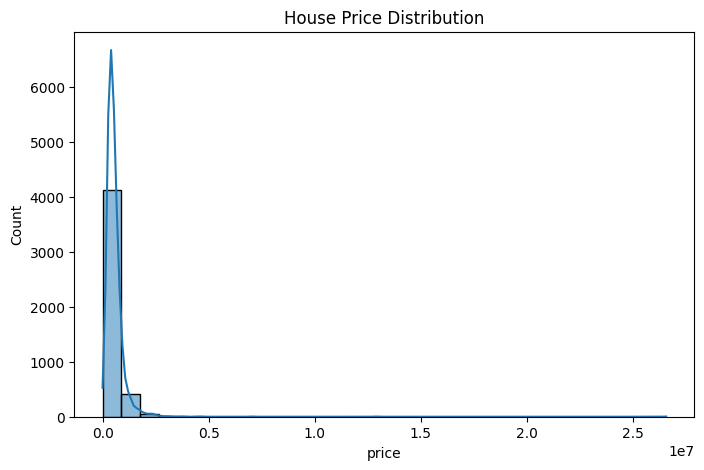

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("House Price Distribution")
plt.show()

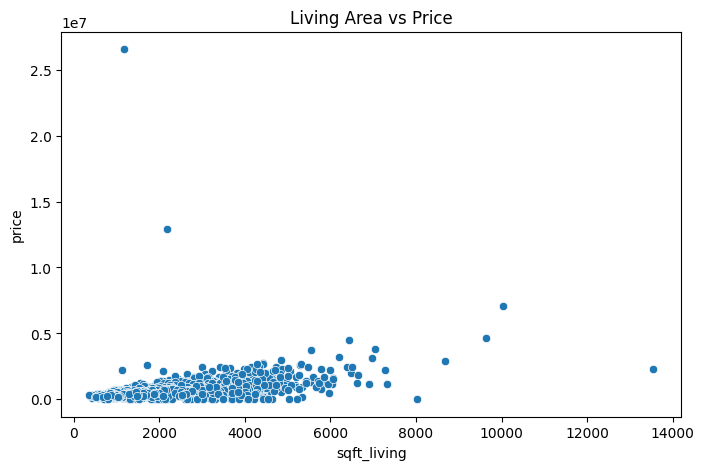

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.title("Living Area vs Price")
plt.show()

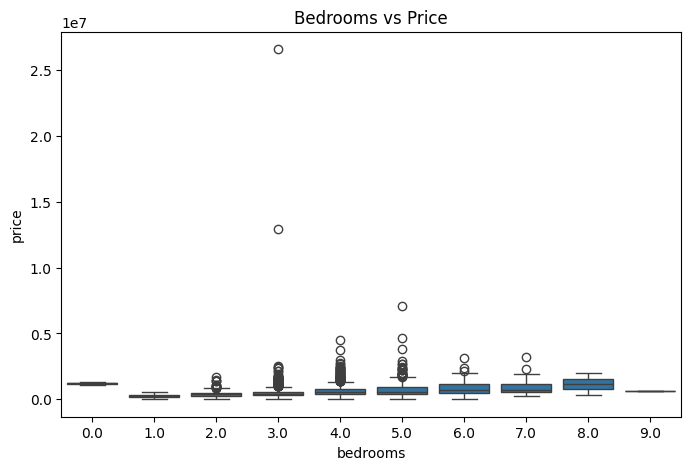

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.title("Bedrooms vs Price")
plt.show()

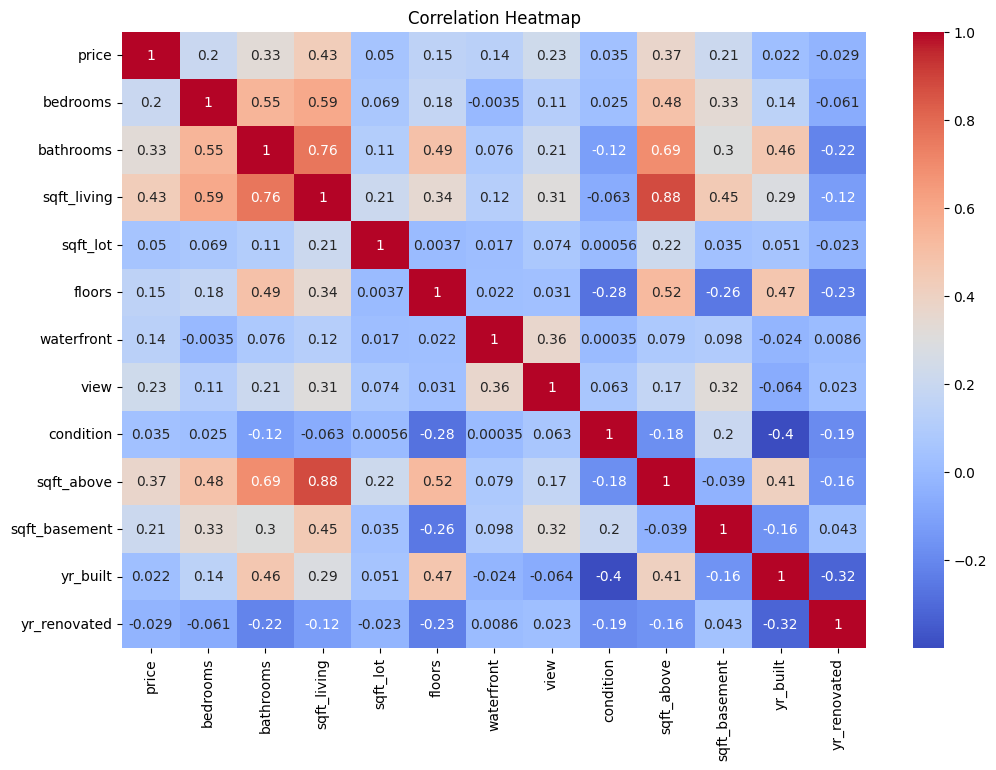

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()
X = df.drop("price", axis=1)
y = df["price"]

print(X.shape)
print(y.shape)

(4600, 17)
(4600,)


In [18]:
X = df.drop("price", axis=1)
y = df["price"]

print(X.shape)
print(y.shape)

(4600, 17)
(4600,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3680, 17)
(920, 17)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

print("Linear Regression Trained Successfully")

Linear Regression Trained Successfully


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Linear Regression")
print("MAE :", mae)
print("RMSE:", rmse)

Linear Regression
MAE : 207816.8294166553
RMSE: 993048.575350367


In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
MAE : 166803.2758949517
RMSE: 988204.1750187094


In [25]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))

print("Gradient Boosting")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)

Gradient Boosting
MAE : 170872.99415203792
RMSE: 984757.6259828946


In [26]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [mae, mae_rf, mae_gb],
    "RMSE": [rmse, rmse_rf, rmse_gb]
})

print(results)

               Model            MAE           RMSE
0  Linear Regression  207816.829417  993048.575350
1      Random Forest  166803.275895  988204.175019
2  Gradient Boosting  170872.994152  984757.625983


In [27]:
import joblib

joblib.dump(rf, "best_house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [29]:
import joblib
import pandas as pd

model = joblib.load("best_house_price_model.pkl")

sample = pd.DataFrame([X.iloc[0]])

prediction = model.predict(sample)

print("Predicted House Price:", prediction[0])

Predicted House Price: 3766634.72


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [30]:
readme = """
# House Price Prediction

## Overview
This project predicts house prices using machine learning.

## Models Used
- Linear Regression
- Random Forest
- Gradient Boosting

## Evaluation Metrics
- MAE
- RMSE

## Files
- House_Price_Prediction.ipynb
- data.csv
- best_house_price_model.pkl
- README.md
"""

with open("README.md", "w") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!
